# Online Retail - RFM User Segmentation Analysis

## Project Overview
End-to-end customer segmentation analysis based on the Online Retail II dataset 
(UCI Machine Learning Repository). 

**Techniques used:** Data cleaning · RFM modeling · User segmentation · Data visualization

**Tools:** Python · pandas · matplotlib · seaborn

## Dataset
- Source: [Online Retail II - Kaggle](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)
- Period: 2009-12-01 to 2011-12-09
- Raw records: 1,067,371 | After cleaning: 805,549

## Key Results
| Segment | Count | % | Median Spend |
|---|---|---|---|
| High-Value | 1,482 | 25.2% | £3,464 |
| Lost | 1,523 | 25.9% | £285 |
| Potential | 1,221 | 20.8% | £1,222 |
| General | 856 | 14.6% | - |
| New | 443 | 7.5% | - |
| At-Risk High-Freq | 353 | 6.0% | - |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("全部ok!")

全部ok!


In [8]:
import os
files = os.listdir(r'C:\Users\86158\Desktop\project1')
for f in files:
    print(f)

online_retail_II.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(r'C:\Users\86158\Desktop\project1\online_retail_II.csv', encoding='utf-8')

print(f"数据加载完成！共 {len(df):,} 行，{df.shape[1]} 列")

数据加载完成！共 1,067,371 行，8 列


In [10]:
print("=== 前5行数据 ===")
display(df.head())

print("\n=== 字段名 ===")
print(df.columns.tolist())

print("\n=== 数据类型 ===")
df.info()

=== 前5行数据 ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



=== 字段名 ===
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

=== 数据类型 ===
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [11]:
print("=== 缺失值统计 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_pct
}).query('缺失数量 > 0')
print(missing_df)

print("\n=== 数值列统计 ===")
display(df.describe())

print("\n=== 时间范围 ===")
print(f"最早：{df['InvoiceDate'].min()}")
print(f"最晚：{df['InvoiceDate'].max()}")

print("\n=== 基本计数 ===")
print(f"唯一客户数：{df['Customer ID'].nunique():,}")
print(f"唯一商品数：{df['StockCode'].nunique():,}")
print(f"唯一发票数：{df['Invoice'].nunique():,}")

=== 缺失值统计 ===
               缺失数量  缺失比例(%)
Description    4382     0.41
Customer ID  243007    22.77

=== 数值列统计 ===


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000



=== 时间范围 ===
最早：2009-12-01 07:45:00
最晚：2011-12-09 12:50:00

=== 基本计数 ===
唯一客户数：5,942
唯一商品数：5,305
唯一发票数：53,628


In [12]:
# 1. 删除没有客户ID的行
df_clean = df.dropna(subset=['Customer ID'])
print(f"删除缺失客户ID后：{len(df_clean):,} 行（删除了 {len(df)-len(df_clean):,} 行）")

# 2. 过滤掉退货单（Invoice 以 C 开头）
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"过滤退货单后：{len(df_clean):,} 行")

# 3. 过滤掉 Quantity 和 Price 为负数或0的异常行
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"过滤异常数值后：{len(df_clean):,} 行")

# 4. 转换日期格式
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. 新增一列：每行的销售金额
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# 6. 转换客户ID为整数
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print(f"\n清洗完成！最终数据：{len(df_clean):,} 行")
print(f"保留比例：{len(df_clean)/len(df)*100:.1f}%")
print(f"\n新增字段 TotalPrice 预览：")
display(df_clean[['Invoice','Customer ID','Quantity','Price','TotalPrice']].head())

删除缺失客户ID后：824,364 行（删除了 243,007 行）
过滤退货单后：805,620 行
过滤异常数值后：805,549 行

清洗完成！最终数据：805,549 行
保留比例：75.5%

新增字段 TotalPrice 预览：


,Invoice,Customer ID,Quantity,Price,TotalPrice
0,489434,13085,12,6.95,83.4
1,489434,13085,12,6.75,81.0
2,489434,13085,12,6.75,81.0
3,489434,13085,48,2.10,100.8
4,489434,13085,24,1.25,30.0


In [13]:
# 以数据集最后一天的次日作为"当前日期"基准
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"基准日期：{snapshot_date.date()}")

rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\nRFM 表前5行：")
display(rfm.head())
print(f"\n共 {len(rfm):,} 位客户")
print(f"\nRFM 基本统计：")
display(rfm[['Recency','Frequency','Monetary']].describe().round(2))

基准日期：2011-12-10

RFM 表前5行：


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40



共 5,878 位客户

RFM 基本统计：


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62
std,209.34,13.01,14737.73
min,1.00,1.00,2.95
25%,26.00,1.00,348.76
50%,96.00,3.00,898.92
75%,380.00,7.00,2307.09
max,739.00,398.00,608821.65


In [14]:
# 每个维度打分 1-5（Recency 越小越好，所以倒序）
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

rfm['RFM_score'] = (rfm['R_score'].astype(str)
                  + rfm['F_score'].astype(str)
                  + rfm['M_score'].astype(str))

# 根据 R/F 分数定义用户类型
def segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    if r >= 4 and f >= 4:
        return '高价值客户'
    elif r >= 4 and f < 3:
        return '新客户'
    elif r < 3 and f >= 4:
        return '流失高频客户'
    elif r >= 3 and f >= 3:
        return '潜力客户'
    elif r < 3 and f < 3:
        return '流失客户'
    else:
        return '一般客户'

rfm['Segment'] = rfm.apply(segment, axis=1)

print("用户分层结果：")
segment_counts = rfm['Segment'].value_counts()
segment_pct = (segment_counts / len(rfm) * 100).round(1)
summary = pd.DataFrame({'客户数': segment_counts, '占比(%)': segment_pct})
display(summary)

用户分层结果：


,客户数,占比(%)
Segment,,
流失客户,1523,25.9
高价值客户,1482,25.2
潜力客户,1221,20.8
一般客户,856,14.6
新客户,443,7.5
流失高频客户,353,6.0


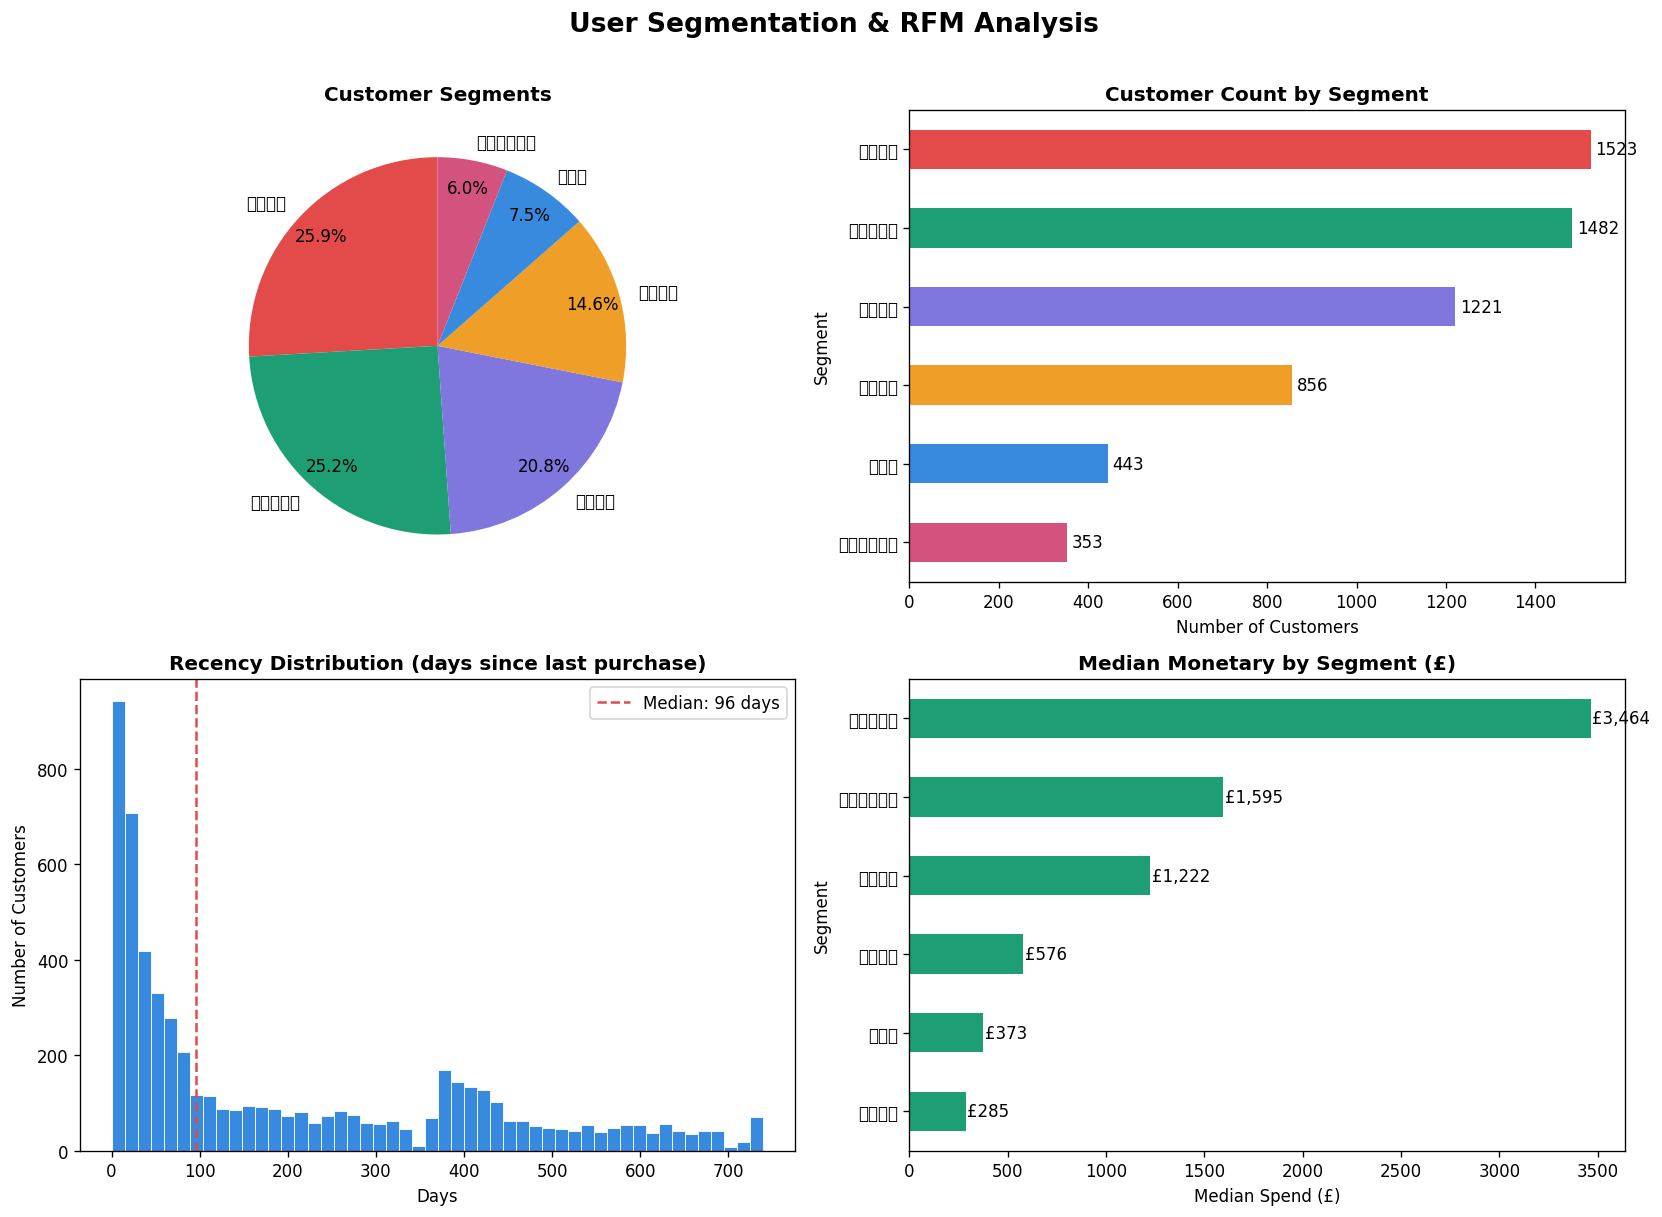

图表已保存为 rfm_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('User Segmentation & RFM Analysis', fontsize=16, fontweight='bold', y=1.01)

# 1. 用户分层饼图
colors = ['#E24B4A','#1D9E75','#7F77DD','#EF9F27','#378ADD','#D4537E']
segment_counts.plot(
    kind='pie', ax=axes[0,0],
    colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.85
)
axes[0,0].set_title('Customer Segments', fontweight='bold')
axes[0,0].set_ylabel('')

# 2. 各分层客户数柱状图
segment_counts.sort_values().plot(
    kind='barh', ax=axes[0,1], color=colors[::-1]
)
axes[0,1].set_title('Customer Count by Segment', fontweight='bold')
axes[0,1].set_xlabel('Number of Customers')
for i, v in enumerate(segment_counts.sort_values()):
    axes[0,1].text(v + 10, i, str(v), va='center', fontsize=10)

# 3. Recency 分布
axes[1,0].hist(rfm['Recency'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Recency Distribution (days since last purchase)', fontweight='bold')
axes[1,0].set_xlabel('Days')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].axvline(rfm['Recency'].median(), color='#E24B4A', linestyle='--', label=f"Median: {rfm['Recency'].median():.0f} days")
axes[1,0].legend()

# 4. 各分层平均消费金额
seg_monetary = rfm.groupby('Segment')['Monetary'].median().sort_values(ascending=True)
seg_monetary.plot(kind='barh', ax=axes[1,1], color='#1D9E75')
axes[1,1].set_title('Median Monetary by Segment (£)', fontweight='bold')
axes[1,1].set_xlabel('Median Spend (£)')
for i, v in enumerate(seg_monetary):
    axes[1,1].text(v + 10, i, f'£{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存为 rfm_analysis.png")

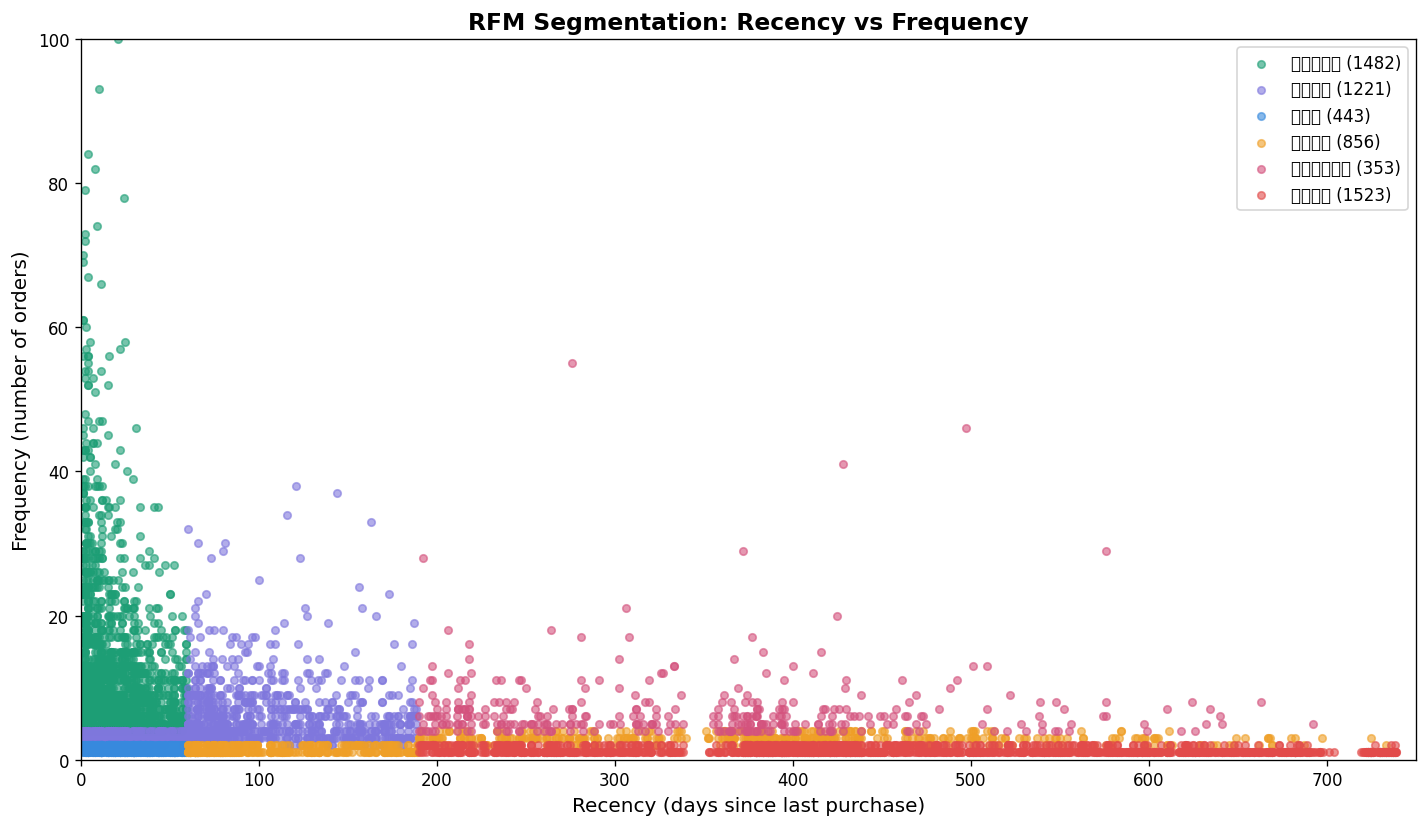

散点图已保存为 rfm_scatter.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

colors_map = {
    '高价值客户':   '#1D9E75',
    '潜力客户':     '#7F77DD',
    '新客户':       '#378ADD',
    '一般客户':     '#EF9F27',
    '流失高频客户': '#D4537E',
    '流失客户':     '#E24B4A',
}

for seg, color in colors_map.items():
    mask = rfm['Segment'] == seg
    ax.scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Frequency'],
        c=color, label=f"{seg} ({mask.sum()})",
        alpha=0.6, s=20
    )

ax.set_title('RFM Segmentation: Recency vs Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency (days since last purchase)', fontsize=12)
ax.set_ylabel('Frequency (number of orders)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 750)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("散点图已保存为 rfm_scatter.png")

In [17]:
print("=" * 55)
print("        ONLINE RETAIL - RFM ANALYSIS SUMMARY")
print("=" * 55)

total = len(rfm)
high_value = rfm[rfm['Segment']=='高价值客户']
lost = rfm[rfm['Segment']=='流失客户']
potential = rfm[rfm['Segment']=='潜力客户']
new = rfm[rfm['Segment']=='新客户']

print(f"""
[DATASET]
  Records after cleaning : {len(df_clean):,}
  Customers analyzed     : {total:,}
  Period                 : 2009-12-01 to 2011-12-09

[KEY FINDINGS]

  1. High-Value Customers ({high_value['Segment'].count():,} users, {high_value['Segment'].count()/total*100:.1f}%)
     - Median spend   : £{high_value['Monetary'].median():,.0f}
     - Median recency : {high_value['Recency'].median():.0f} days
     - Median orders  : {high_value['Frequency'].median():.0f}
     → These customers drive disproportionate revenue.
       Priority: loyalty programs & early access offers.

  2. At-Risk / Lost Customers ({lost['Segment'].count():,} users, {lost['Segment'].count()/total*100:.1f}%)
     - Median recency : {lost['Recency'].median():.0f} days since last purchase
     - Median spend   : £{lost['Monetary'].median():,.0f}
     → High churn signal. Re-engagement campaigns
       (discount vouchers, win-back emails) recommended.

  3. Potential Customers ({potential['Segment'].count():,} users, {potential['Segment'].count()/total*100:.1f}%)
     - Median spend   : £{potential['Monetary'].median():,.0f}
     - Median orders  : {potential['Frequency'].median():.0f}
     → Mid-tier with growth potential.
       Cross-sell & upsell strategies applicable.

  4. New Customers ({new['Segment'].count():,} users, {new['Segment'].count()/total*100:.1f}%)
     - Median recency : {new['Recency'].median():.0f} days
     → Recently acquired. Onboarding sequences
       and first-repeat-purchase incentives advised.

[RECOMMENDATIONS]
  - Focus retention budget on High-Value segment (25%)
  - Launch win-back campaign for Lost segment (26%)
  - Upgrade Potential customers via targeted promotions
  - Track New customers' second-purchase conversion rate
""")
print("=" * 55)

        ONLINE RETAIL - RFM ANALYSIS SUMMARY

[DATASET]
  Records after cleaning : 805,549
  Customers analyzed     : 5,878
  Period                 : 2009-12-01 to 2011-12-09

[KEY FINDINGS]

  1. High-Value Customers (1,482 users, 25.2%)
     - Median spend   : £3,464
     - Median recency : 17 days
     - Median orders  : 10
     → These customers drive disproportionate revenue.
       Priority: loyalty programs & early access offers.

  2. At-Risk / Lost Customers (1,523 users, 25.9%)
     - Median recency : 435 days since last purchase
     - Median spend   : £285
     → High churn signal. Re-engagement campaigns
       (discount vouchers, win-back emails) recommended.

  3. Potential Customers (1,221 users, 20.8%)
     - Median spend   : £1,222
     - Median orders  : 4
     → Mid-tier with growth potential.
       Cross-sell & upsell strategies applicable.

  4. New Customers (443 users, 7.5%)
     - Median recency : 26 days
     → Recently acquired. Onboarding sequences
       